In [2]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0003
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 64

In [5]:
# quantization bits
bits_G = 8   # generator linear weights quantized to this many bits
bits_C = 8   # critic linear weights quantized to this many bits

In [6]:
# WGAN-specific
n_critic = 5        # number of critic updates per generator update
clip_value = 0.01   # weight clipping range [-clip_value, clip_value]
img_size = 28*28

In [7]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [8]:
# STE quantizer (symmetric per-tensor)
class SymmetricQuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, bits):
        if bits is None or bits >= 32:
            return x
        if bits <= 0:
            return torch.zeros_like(x)
        qlevels = 2 ** (bits - 1) - 1
        max_val = x.abs().max()
        if max_val == 0:
            return torch.zeros_like(x)
        scale = max_val / float(qlevels)
        if scale == 0:
            return torch.zeros_like(x)
        q = torch.round(x / scale).clamp(-qlevels, qlevels) * scale
        return q
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

quantize_ste = SymmetricQuantizeSTE.apply

# QLinear wrapper
class QLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, bits=8):
        super().__init__()
        self.bits = bits
        self.linear = nn.Linear(in_features, out_features, bias=bias)
    def forward(self, x):
        qw = quantize_ste(self.linear.weight, self.bits)
        return F.linear(x, qw, self.linear.bias)

# weight init helpers
def init_weights(m):
    if isinstance(m, (nn.Linear, QLinear)):
        if isinstance(m, QLinear):
            nn.init.normal_(m.linear.weight.data, 0.0, 0.02)
            if m.linear.bias is not None: nn.init.constant_(m.linear.bias.data, 0)
        else:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            if m.bias is not None: nn.init.constant_(m.bias.data, 0)
    if isinstance(m, nn.BatchNorm1d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Quantized Generator (MLP)
class GeneratorQ(nn.Module):
    def __init__(self, z_dim=latent_dim, bits=8):
        super().__init__()
        self.net = nn.Sequential(
            # use QLinear here
            QLinear(latent_dim, 128, bits=bits),
            nn.ReLU(True),
            QLinear(128, 256, bits=bits),
            nn.ReLU(True),
            QLinear(256, 28*28, bits=bits),
            nn.Tanh()  # output lung range [-1,1]
        )
    def forward(self, z):
        if z.dim() == 2:
            out = self.net(z)
        else:
            out = self.net(z.view(z.size(0), -1))
        return out.view(z.size(0), 1, 28, 28)

# Quantized Critic
class CriticQ(nn.Module):
    def __init__(self, bits=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            QLinear(img_size, 256, bits=bits),
            nn.LeakyReLU(0.2, inplace=True),
            QLinear(256, 128, bits=bits),
            nn.LeakyReLU(0.2, inplace=True),
            QLinear(128, 1, bits=bits)   # raw score
        )
    def forward(self, img):
        return self.net(img).view(img.size(0), 1)

In [9]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = GeneratorQ(bits=bits_G).to(device)
critic = CriticQ(bits=bits_C).to(device)
generator.apply(init_weights)
critic.apply(init_weights)

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_C = optim.Adam(critic.parameters(), lr=lr)

In [10]:
def model_params_size_bytes_quant(model, bits):
    # Only count parameters (not buffers) for quantized weights
    params = sum(p.numel() * bits for p in model.parameters()) // 8  # bits to bytes
    buffers = sum(b.numel() * p.element_size() for b in model.buffers())  # buffers usually float32
    return params + buffers

def n_parameters_approx_quant(n_MB: float, bits: int):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = (n_Bytes * 8) // bits
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes_quant(generator, bits_G))
critic_parameters_size = bytes_to_mb(model_params_size_bytes_quant(critic, bits_C))
total_size = generator_parameters_size + critic_parameters_size

print(f"Numbers of parameters (approx): {n_parameters_approx_quant(total_size, max(bits_G, bits_C)):,}")
print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tCritic (Discriminator): {critic_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")

Numbers of parameters (approx): 481,425
Model size (MB):
	Generator: 0.24 (MB)
	Critic (Discriminator): 0.22 (MB)
	Total: 0.46 (MB)


In [11]:
# Storage for metrics
history = {'epoch': 0, 'loss_C': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_C: -0.4325, Loss_G: -2.9683, Time: 18.29s


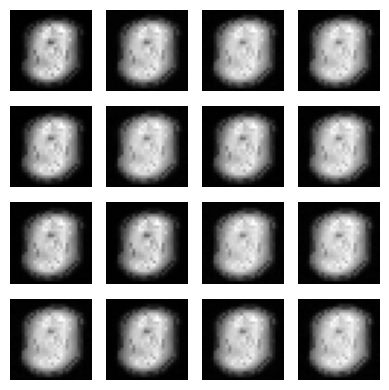

[Epoch 20/300] Loss_C: -0.3670, Loss_G: 0.0889, Time: 397.43s


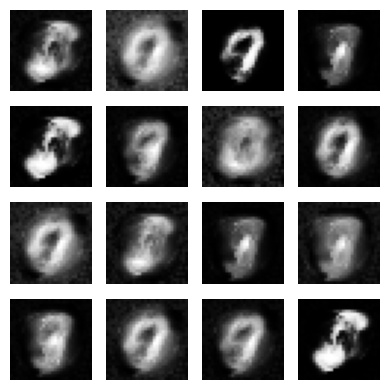

[Epoch 40/300] Loss_C: -0.2824, Loss_G: -0.0248, Time: 756.53s


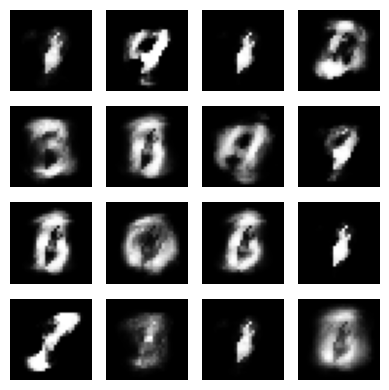

[Epoch 60/300] Loss_C: -0.1712, Loss_G: -0.0114, Time: 1152.87s


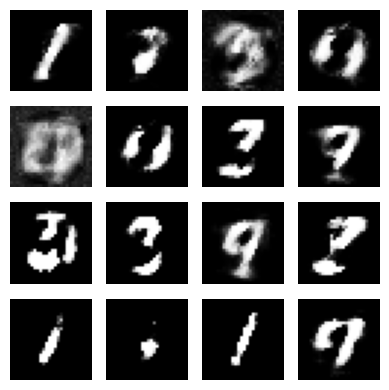

[Epoch 80/300] Loss_C: -0.1290, Loss_G: 0.0108, Time: 1514.95s


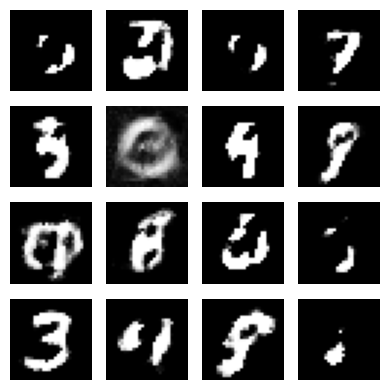

[Epoch 100/300] Loss_C: -0.1175, Loss_G: 0.0625, Time: 1881.59s


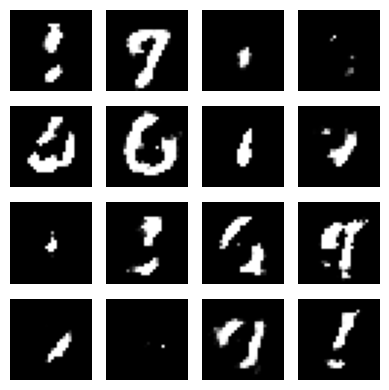

[Epoch 120/300] Loss_C: -0.2143, Loss_G: -0.5979, Time: 2244.57s


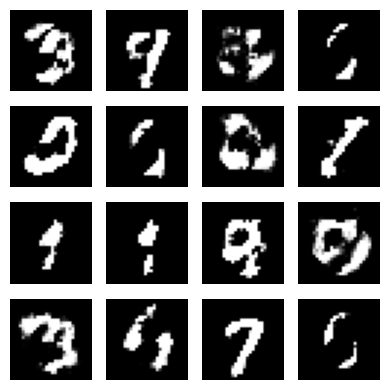

[Epoch 140/300] Loss_C: -0.1869, Loss_G: -0.8533, Time: 2598.58s


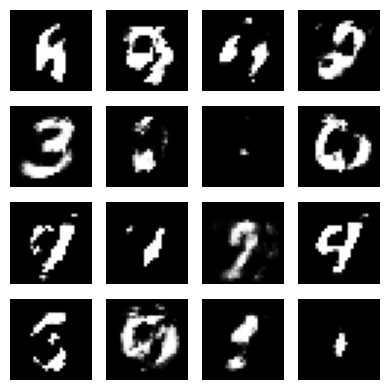

[Epoch 160/300] Loss_C: -0.1368, Loss_G: -0.6976, Time: 2961.52s


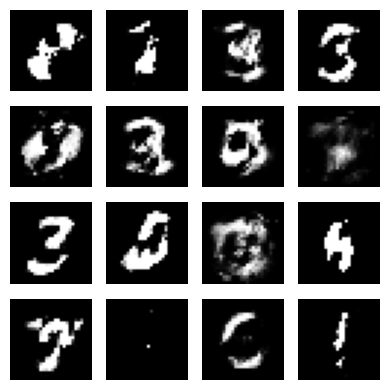

[Epoch 180/300] Loss_C: -0.1222, Loss_G: 0.0161, Time: 3313.75s


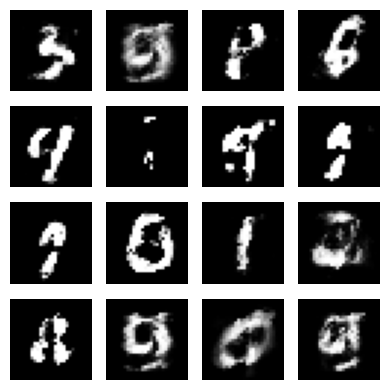

[Epoch 200/300] Loss_C: -0.1726, Loss_G: -0.4899, Time: 3669.60s


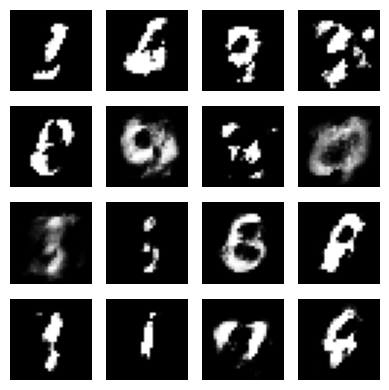

[Epoch 220/300] Loss_C: -0.0860, Loss_G: -0.1085, Time: 4062.78s


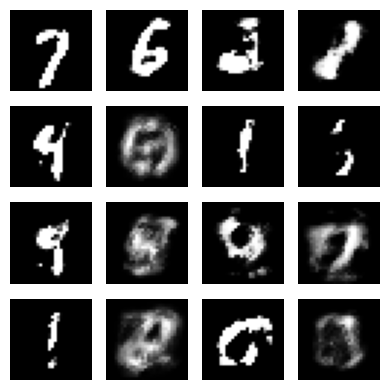

[Epoch 240/300] Loss_C: -0.0806, Loss_G: -0.1099, Time: 4447.62s


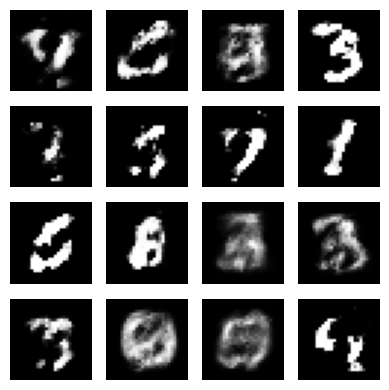

[Epoch 260/300] Loss_C: -0.3552, Loss_G: -4.1007, Time: 4819.91s


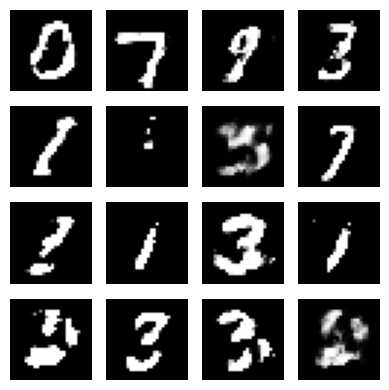

[Epoch 280/300] Loss_C: -0.1178, Loss_G: -5.1327, Time: 5184.18s


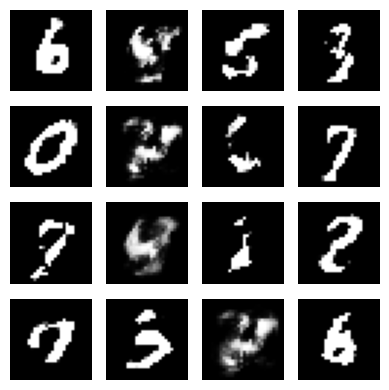

[Epoch 300/300] Loss_C: -0.0049, Loss_G: 0.2283, Time: 5604.17s


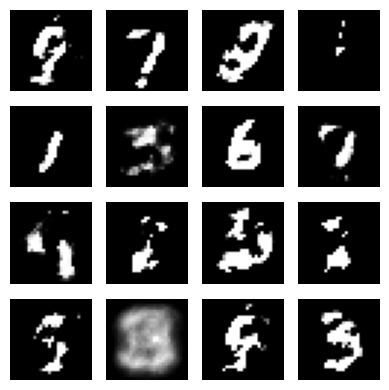

In [13]:
t0 = time.perf_counter()
for epoch in range(1, epochs+1):
    epoch_loss_C = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        for _ in range(n_critic):
            z = torch.randn(b, latent_dim, device=device)
            gen_imgs = generator(z).detach()

            optimizer_C.zero_grad()
            real_scores = critic(real_imgs)
            fake_scores = critic(gen_imgs)
            loss_C = fake_scores.mean() - real_scores.mean()
            loss_C.backward()
            optimizer_C.step()

            # clip critic weights (clip performed on floating weights inside wrappers)
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)
            epoch_loss_C += loss_C.item()

        # generator update
        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)
        optimizer_G.zero_grad()
        loss_G = -critic(gen_imgs).mean()
        loss_G.backward()
        optimizer_G.step()
        epoch_loss_G += loss_G.item()

    num_batches = len(train_loader)
    avg_loss_C = epoch_loss_C / (num_batches * n_critic)
    avg_loss_G = epoch_loss_G / num_batches
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_C'].append(avg_loss_C)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    if epoch == 1 or epoch % 20 == 0:
        print(f"[Epoch {epoch}/{epochs}] Loss_C: {avg_loss_C:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            samples = generator(test_z).cpu()
        fig, axes = plt.subplots(4,4,figsize=(4,4))
        for img,ax in zip(samples, axes.flatten()):
            ax.imshow(img.squeeze()*0.5 + 0.5, cmap='gray'); ax.axis('off')
        plt.tight_layout(); plt.show()

ValueError: x and y must have same first dimension, but have shapes (300,) and (301,)

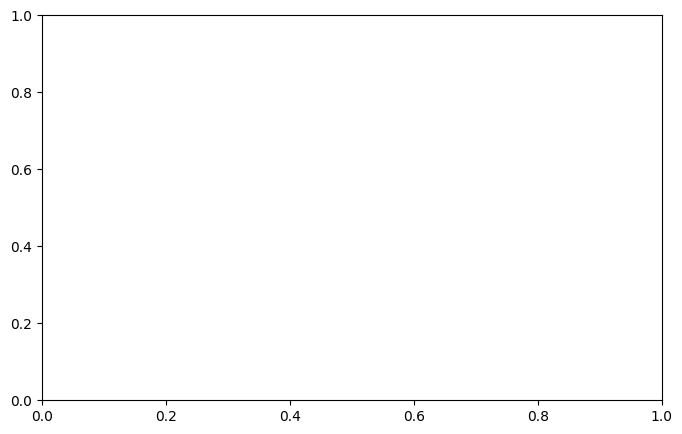

In [14]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_C'], label='Critic Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

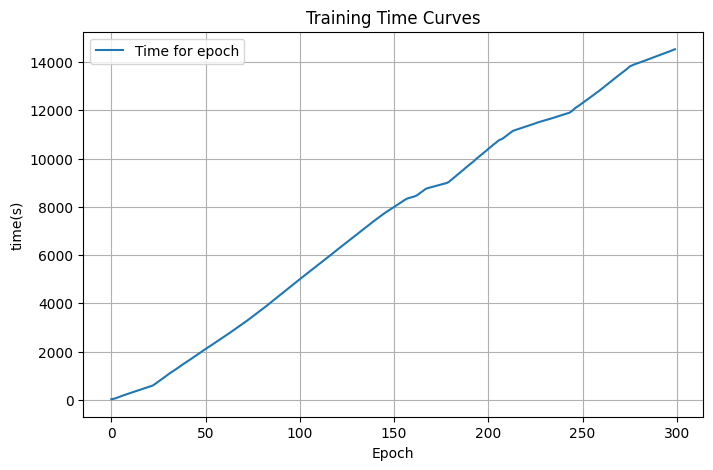

In [ ]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [ ]:
# Export to CSV
csv_file = 'QGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_C', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_C'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_C': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to QGAN_training_history.csv
